# Breast Cancer TSV Dataset — Binary Classification with Validation Checkpoints

This notebook trains a one-hidden-layer PyTorch MLP on a binary breast cancer classification TSV dataset.

Expected dataset file:

```text
breast_cancer.tsv
```

Expected structure:

```text
9 feature columns + 1 binary target column
```

Target encoding:

```text
0 = False
1 = True
```

The notebook uses a validation set to detect overfitting and implements checkpointing:

- after the first epoch, a checkpoint is saved;
- after that, a checkpoint is saved if and only if validation balanced accuracy is strictly higher than the validation balanced accuracy of the previously saved checkpoint;
- the best checkpoint is reloaded from disk after the final epoch;
- the reloaded best checkpoint is then applied to the held-out test set.

## Split

```text
64% training
16% validation
20% final testing
```

The final test set is not used during training or checkpoint selection.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## 1. User settings

In [2]:
# =========================
# User-configurable settings
# =========================

DATASET_FILE = "breast_cancer.tsv"

# MLP architecture
INPUT_NEURONS = 9
OUTPUT_NEURONS = 1
HIDDEN_NEURONS = 16

# Choose one of:
# "relu", "leaky_relu", "gelu", "tanh", "sigmoid"
HIDDEN_ACTIVATION = "relu"

# Training settings
EPOCHS = 500
BATCH_SIZE = 8
LEARNING_RATE = 0.0005

# Reproducibility
RANDOM_SEED = 42

# Dataset split
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_TRAINING_POOL = 0.20

# Binary classification threshold
CLASSIFICATION_THRESHOLD = 0.5

# The best checkpoint is overwritten whenever validation balanced accuracy improves.
CHECKPOINT_PATH = "breast_cancer_best_validation_balanced_accuracy_checkpoint.pt"

# After the last epoch, this notebook reloads the best checkpoint from disk
# and applies that checkpoint to the final held-out test set.
LOAD_BEST_CHECKPOINT_AFTER_TRAINING = True

## 2. Reproducibility and device setup

In [3]:
def set_random_seed(seed: int):
    """Set random seeds for Python, NumPy and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_random_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 3. Load the TSV dataset

In [4]:
def load_breast_cancer_tsv(filename: str):
    """
    Load a binary breast cancer TSV dataset.

    Expected:
    - 9 feature columns
    - 1 binary target column
    - target values are 0 and 1

    Supports:
    - headerless TSV
    - TSV with a header row
    """
    dataset_path = Path(filename)

    if not dataset_path.exists():
        raise FileNotFoundError(
            f"Could not find {filename}. Place the file in the same directory as this notebook, "
            "or update DATASET_FILE."
        )

    # First try headerless format.
    try:
        df = pd.read_csv(dataset_path, sep="\t", header=None)

        if df.shape[1] != INPUT_NEURONS + OUTPUT_NEURONS:
            raise ValueError(
                f"Expected {INPUT_NEURONS + OUTPUT_NEURONS} columns, found {df.shape[1]}."
            )

        X = df.iloc[:, :INPUT_NEURONS].astype(np.float32).values
        y = df.iloc[:, INPUT_NEURONS].astype(np.float32).values.reshape(-1, 1)
        feature_names = [f"feature_{i}" for i in range(1, INPUT_NEURONS + 1)]

    except Exception:
        print("Headerless loading failed. Trying again assuming the TSV has a header row.")
        df = pd.read_csv(dataset_path, sep="\t", header=0)

        if df.shape[1] != INPUT_NEURONS + OUTPUT_NEURONS:
            raise ValueError(
                f"Expected {INPUT_NEURONS + OUTPUT_NEURONS} columns, found {df.shape[1]}."
            )

        X = df.iloc[:, :INPUT_NEURONS].astype(np.float32).values
        y = df.iloc[:, INPUT_NEURONS].astype(np.float32).values.reshape(-1, 1)
        feature_names = list(df.columns[:INPUT_NEURONS])

    unique_targets = np.unique(y)

    if not set(unique_targets).issubset({0.0, 1.0}):
        raise ValueError(f"Expected binary targets 0 and 1 only. Found: {unique_targets}")

    return X, y, df, feature_names


X, y, df, feature_names = load_breast_cancer_tsv(DATASET_FILE)

print("Dataset loaded successfully.")
print(f"Full dataframe shape: {df.shape}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

print("\nFeature names:")
print(feature_names)

print("\nClass distribution:")
print(pd.Series(y.flatten()).value_counts().sort_index())

Headerless loading failed. Trying again assuming the TSV has a header row.
Dataset loaded successfully.
Full dataframe shape: (286, 10)
Feature matrix shape: (286, 9)
Target vector shape: (286, 1)

Feature names:
['age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps', 'deg-malig', 'breast', 'breast-quad', 'irradiat']

Class distribution:
0.0    201
1.0     85
Name: count, dtype: int64


## 4. Inspect the first few rows

In [5]:
df.head()

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,target
0,2,2,2,0,2,3,1,3,0,1
1,3,0,2,0,1,1,1,1,0,0
2,3,0,6,0,1,2,0,2,0,1
3,2,2,6,0,2,3,1,2,1,0
4,2,2,5,4,2,2,0,5,0,1


## 5. Train / validation / test split and feature scaling

In [6]:
# First split: 80% train+validation pool, 20% final test set.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

# Second split: from the 80% train+validation pool, take 20% for validation.
# Overall result: 64% training, 16% validation, 20% testing.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=VALIDATION_SIZE_WITHIN_TRAINING_POOL,
    random_state=RANDOM_SEED,
    stratify=y_train_val
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print(f"Training samples:   {X_train_scaled.shape[0]}")
print(f"Validation samples: {X_val_scaled.shape[0]}")
print(f"Testing samples:    {X_test_scaled.shape[0]}")

print("\nTraining class distribution:")
print(pd.Series(y_train.flatten()).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val.flatten()).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test.flatten()).value_counts().sort_index())

Training samples:   182
Validation samples: 46
Testing samples:    58

Training class distribution:
0.0    128
1.0     54
Name: count, dtype: int64

Validation class distribution:
0.0    32
1.0    14
Name: count, dtype: int64

Testing class distribution:
0.0    41
1.0    17
Name: count, dtype: int64


## 6. Convert arrays to PyTorch tensors and create the training DataLoader

In [7]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

data_loader_generator = torch.Generator()
data_loader_generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=data_loader_generator
)

print(f"Number of training batches per epoch: {len(train_loader)}")

Number of training batches per epoch: 23


## 7. Define the MLP model

In [8]:
def get_activation_function(name: str):
    """Return the requested activation function."""
    name = name.lower()

    if name == "relu":
        return nn.ReLU()
    elif name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.01)
    elif name == "gelu":
        return nn.GELU()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "sigmoid":
        return nn.Sigmoid()
    else:
        raise ValueError(
            "Unknown activation function. Choose from: "
            "'relu', 'leaky_relu', 'gelu', 'tanh', 'sigmoid'."
        )


class BinaryMLP(nn.Module):
    def __init__(self, input_neurons, hidden_neurons, output_neurons, activation_name):
        super().__init__()

        if output_neurons != 1:
            raise ValueError("For binary classification, output_neurons should be 1.")

        self.hidden = nn.Linear(input_neurons, hidden_neurons, bias=True)
        self.activation = get_activation_function(activation_name)
        self.output = nn.Linear(hidden_neurons, output_neurons, bias=True)

    def forward(self, x):
        x = self.hidden(x)
        x = self.activation(x)
        logits = self.output(x)
        return logits


# Set the random seed immediately before model creation so weight initialisation is controlled.
set_random_seed(RANDOM_SEED)

model = BinaryMLP(
    input_neurons=INPUT_NEURONS,
    hidden_neurons=HIDDEN_NEURONS,
    output_neurons=OUTPUT_NEURONS,
    activation_name=HIDDEN_ACTIVATION
).to(device)

print(model)

print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

BinaryMLP(
  (hidden): Linear(in_features=9, out_features=16, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=16, out_features=1, bias=True)
)

Total parameters: 177
Trainable parameters: 177


## 8. Loss function and optimizer

In [9]:
# BCEWithLogitsLoss expects raw logits, so the model does not include a final sigmoid.
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 9. Evaluation helper

In [10]:
def evaluate_model(model, X_tensor, y_tensor, threshold=0.5):
    """Evaluate the model and return accuracy, balanced accuracy, y_true, and y_pred."""
    model.eval()

    X_tensor = X_tensor.to(device)
    y_tensor = y_tensor.to(device)

    with torch.no_grad():
        logits = model(X_tensor)
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= threshold).int()

    y_true = y_tensor.detach().cpu().numpy().astype(int).flatten()
    y_pred = predictions.detach().cpu().numpy().astype(int).flatten()

    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

    return accuracy, balanced_accuracy, y_true, y_pred

## 10. Checkpoint helper

In [11]:
def save_checkpoint(
    checkpoint_path,
    epoch,
    model,
    optimizer,
    scaler,
    train_loss,
    train_accuracy,
    validation_accuracy,
    train_balanced_accuracy,
    validation_balanced_accuracy
):
    """Save a checkpoint to disk."""
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),

        "input_neurons": INPUT_NEURONS,
        "hidden_neurons": HIDDEN_NEURONS,
        "output_neurons": OUTPUT_NEURONS,
        "hidden_activation": HIDDEN_ACTIVATION,

        "classification_threshold": CLASSIFICATION_THRESHOLD,
        "random_seed": RANDOM_SEED,

        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "validation_accuracy": validation_accuracy,
        "train_balanced_accuracy": train_balanced_accuracy,
        "validation_balanced_accuracy": validation_balanced_accuracy,

        # Save the scaler because future inference must use the same scaling.
        "scaler": scaler,
        "feature_names": feature_names,
    }

    torch.save(checkpoint, checkpoint_path)

## 11. Training loop with validation monitoring and checkpointing

In [12]:
history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_balanced_accuracy": [],
    "val_balanced_accuracy": [],
    "checkpoint_saved": []
}

checkpoint_history = []

best_checkpoint_validation_balanced_accuracy = -np.inf
best_checkpoint_epoch = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_X.size(0)

    average_train_loss = total_loss / len(train_loader.dataset)

    train_acc, train_bal_acc, _, _ = evaluate_model(
        model,
        X_train_tensor,
        y_train_tensor,
        threshold=CLASSIFICATION_THRESHOLD
    )

    val_acc, val_bal_acc, _, _ = evaluate_model(
        model,
        X_val_tensor,
        y_val_tensor,
        threshold=CLASSIFICATION_THRESHOLD
    )

    # Strict improvement rule:
    # - the first epoch saves because the previous best is -infinity;
    # - subsequent epochs save only if validation balanced accuracy strictly improves.
    checkpoint_saved = False

    if val_bal_acc > best_checkpoint_validation_balanced_accuracy:
        save_checkpoint(
            checkpoint_path=CHECKPOINT_PATH,
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            scaler=scaler,
            train_loss=average_train_loss,
            train_accuracy=train_acc,
            validation_accuracy=val_acc,
            train_balanced_accuracy=train_bal_acc,
            validation_balanced_accuracy=val_bal_acc
        )

        checkpoint_saved = True
        best_checkpoint_validation_balanced_accuracy = val_bal_acc
        best_checkpoint_epoch = epoch

        checkpoint_history.append({
            "epoch": epoch,
            "validation_balanced_accuracy": val_bal_acc,
            "validation_accuracy": val_acc,
            "training_balanced_accuracy": train_bal_acc,
            "training_accuracy": train_acc,
            "training_loss": average_train_loss,
            "checkpoint_path": CHECKPOINT_PATH
        })

    history["epoch"].append(epoch)
    history["train_loss"].append(average_train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)
    history["train_balanced_accuracy"].append(train_bal_acc)
    history["val_balanced_accuracy"].append(val_bal_acc)
    history["checkpoint_saved"].append(checkpoint_saved)

    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS or checkpoint_saved:
        checkpoint_message = " | CHECKPOINT SAVED" if checkpoint_saved else ""
        print(
            f"Epoch {epoch:4d} | "
            f"Loss: {average_train_loss:.6f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Train Bal Acc: {train_bal_acc:.4f} | "
            f"Val Bal Acc: {val_bal_acc:.4f}"
            f"{checkpoint_message}"
        )

print("\nBest checkpoint")
print("===============")
print(f"Best checkpoint epoch: {best_checkpoint_epoch}")
print(f"Best checkpoint validation balanced accuracy: {best_checkpoint_validation_balanced_accuracy:.4f}")
print(f"Checkpoint file: {CHECKPOINT_PATH}")

Epoch    1 | Loss: 0.652098 | Train Acc: 0.7143 | Val Acc: 0.6087 | Train Bal Acc: 0.5399 | Val Bal Acc: 0.4777 | CHECKPOINT SAVED
Epoch    3 | Loss: 0.635973 | Train Acc: 0.7143 | Val Acc: 0.6304 | Train Bal Acc: 0.5346 | Val Bal Acc: 0.4933 | CHECKPOINT SAVED
Epoch   10 | Loss: 0.590054 | Train Acc: 0.7308 | Val Acc: 0.6522 | Train Bal Acc: 0.5570 | Val Bal Acc: 0.4888
Epoch   11 | Loss: 0.583734 | Train Acc: 0.7363 | Val Acc: 0.6739 | Train Bal Acc: 0.5663 | Val Bal Acc: 0.5246 | CHECKPOINT SAVED
Epoch   17 | Loss: 0.553652 | Train Acc: 0.7747 | Val Acc: 0.6957 | Train Bal Acc: 0.6311 | Val Bal Acc: 0.5603 | CHECKPOINT SAVED
Epoch   20 | Loss: 0.541696 | Train Acc: 0.7747 | Val Acc: 0.6957 | Train Bal Acc: 0.6364 | Val Bal Acc: 0.5603
Epoch   23 | Loss: 0.531393 | Train Acc: 0.7692 | Val Acc: 0.7174 | Train Bal Acc: 0.6432 | Val Bal Acc: 0.5960 | CHECKPOINT SAVED
Epoch   30 | Loss: 0.513400 | Train Acc: 0.7692 | Val Acc: 0.7174 | Train Bal Acc: 0.6539 | Val Bal Acc: 0.5960
Epoch   4

## 12. Training history

In [13]:
history_df = pd.DataFrame(history)
history_df.head()

,epoch,train_loss,train_accuracy,val_accuracy,train_balanced_accuracy,val_balanced_accuracy,checkpoint_saved
0,1,0.652098,0.714286,0.608696,0.539931,0.477679,True
1,2,0.643999,0.719780,0.608696,0.543837,0.477679,False
2,3,0.635973,0.714286,0.630435,0.534578,0.493304,True
3,4,0.629218,0.725275,0.630435,0.542390,0.493304,False
4,5,0.622035,0.719780,0.630435,0.533131,0.473214,False


## 13. Checkpoint history

In [14]:
checkpoint_history_df = pd.DataFrame(checkpoint_history)
checkpoint_history_df

,epoch,validation_balanced_accuracy,validation_accuracy,training_balanced_accuracy,training_accuracy,training_loss,checkpoint_path
0,1,0.477679,0.608696,0.539931,0.714286,0.652098,breast_cancer_best_validation_balanced_accurac...
1,3,0.493304,0.630435,0.534578,0.714286,0.635973,breast_cancer_best_validation_balanced_accurac...
2,11,0.524554,0.673913,0.566262,0.736264,0.583734,breast_cancer_best_validation_balanced_accurac...
3,17,0.560268,0.695652,0.631076,0.774725,0.553652,breast_cancer_best_validation_balanced_accurac...
4,23,0.595982,0.717391,0.643229,0.769231,0.531393,breast_cancer_best_validation_balanced_accurac...
5,41,0.616071,0.717391,0.646123,0.758242,0.495517,breast_cancer_best_validation_balanced_accurac...
6,93,0.647321,0.760870,0.713397,0.807692,0.448857,breast_cancer_best_validation_balanced_accurac...
7,140,0.683036,0.782609,0.709491,0.802198,0.417949,breast_cancer_best_validation_balanced_accurac...
8,143,0.718750,0.804348,0.709491,0.802198,0.416462,breast_cancer_best_validation_balanced_accurac...


## 14. Plot training balanced accuracy versus validation balanced accuracy

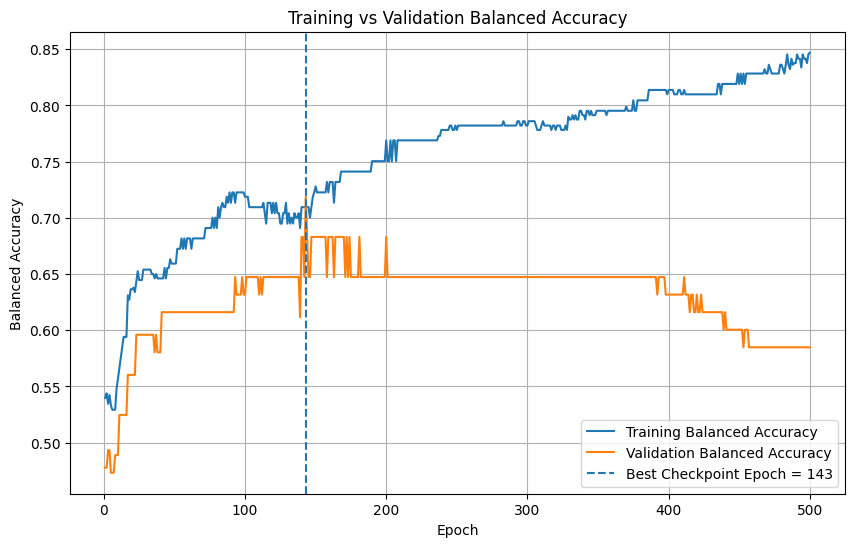

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_balanced_accuracy"],
    label="Training Balanced Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_balanced_accuracy"],
    label="Validation Balanced Accuracy"
)

plt.axvline(
    x=best_checkpoint_epoch,
    linestyle="--",
    label=f"Best Checkpoint Epoch = {best_checkpoint_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title("Training vs Validation Balanced Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 15. Plot validation balanced accuracy at saved checkpoints

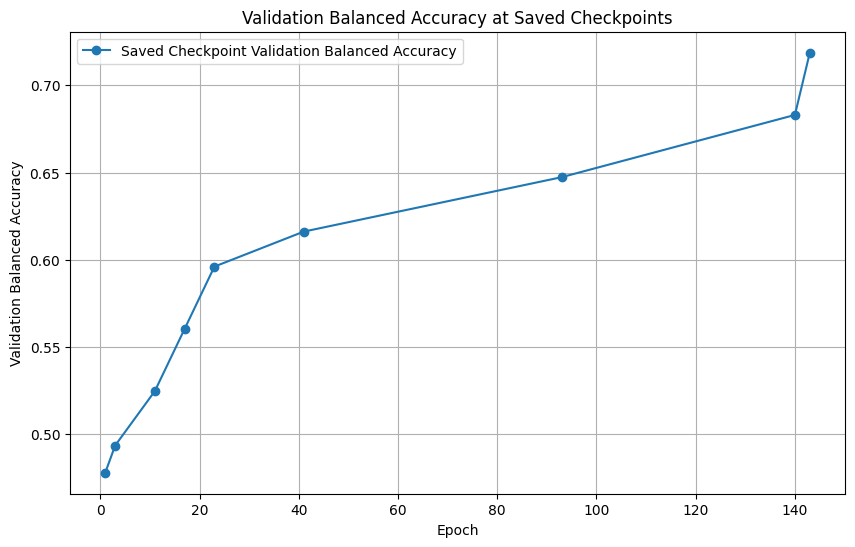

In [16]:
if not checkpoint_history_df.empty:
    plt.figure(figsize=(10, 6))

    plt.plot(
        checkpoint_history_df["epoch"],
        checkpoint_history_df["validation_balanced_accuracy"],
        marker="o",
        label="Saved Checkpoint Validation Balanced Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Balanced Accuracy")
    plt.title("Validation Balanced Accuracy at Saved Checkpoints")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No checkpoints were saved.")

## 16. Plot training and validation accuracy

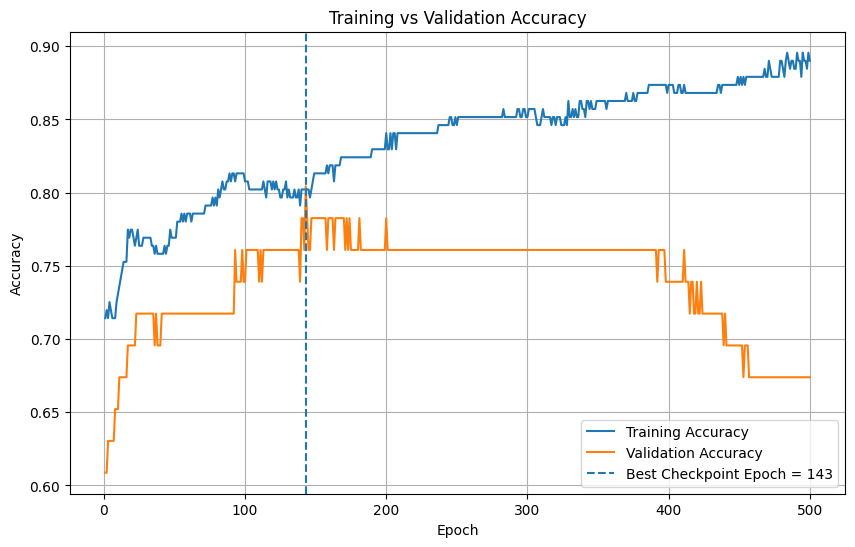

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Training Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")

plt.axvline(
    x=best_checkpoint_epoch,
    linestyle="--",
    label=f"Best Checkpoint Epoch = {best_checkpoint_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 17. Plot training loss

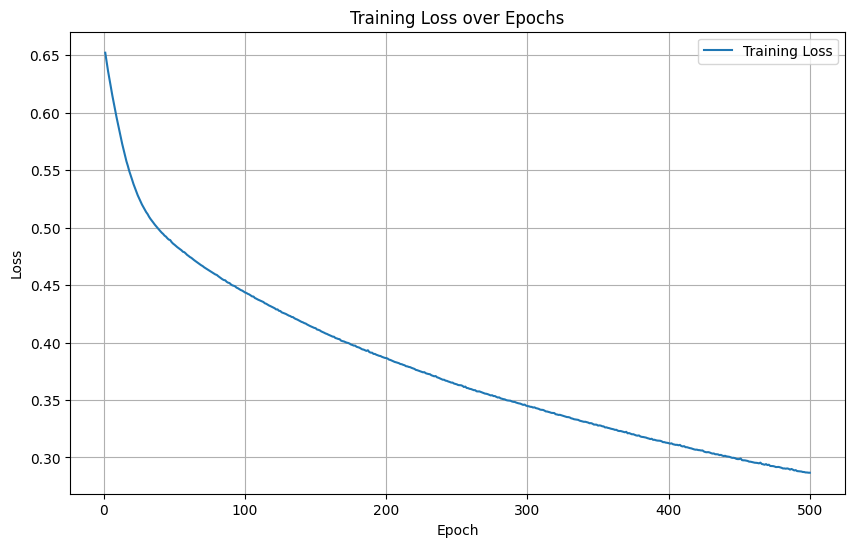

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.legend()
plt.grid(True)
plt.show()

## 18. Load the best checkpoint after the final epoch

In [19]:
# This cell is deliberately placed after the training loop.
# It reloads the best checkpoint saved during training.

checkpoint_path = Path(CHECKPOINT_PATH)

if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint file not found: {CHECKPOINT_PATH}")

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

print("Best checkpoint loaded from disk.")
print(f"Checkpoint epoch: {checkpoint['epoch']}")
print(f"Checkpoint validation balanced accuracy: {checkpoint['validation_balanced_accuracy']:.4f}")
print(f"Checkpoint validation accuracy: {checkpoint['validation_accuracy']:.4f}")

if LOAD_BEST_CHECKPOINT_AFTER_TRAINING:
    model.load_state_dict(checkpoint["model_state_dict"])
    print("\nModel weights restored from the best checkpoint.")
else:
    print("\nBest checkpoint loaded, but model weights from the final epoch are still being used.")

Best checkpoint loaded from disk.
Checkpoint epoch: 143
Checkpoint validation balanced accuracy: 0.7188
Checkpoint validation accuracy: 0.8043

Model weights restored from the best checkpoint.


## 19. Apply the best checkpoint to the final test set

In [20]:
# This evaluation uses the model weights restored from the best validation checkpoint.

final_train_acc, final_train_bal_acc, _, _ = evaluate_model(
    model,
    X_train_tensor,
    y_train_tensor,
    threshold=CLASSIFICATION_THRESHOLD
)

final_val_acc, final_val_bal_acc, _, _ = evaluate_model(
    model,
    X_val_tensor,
    y_val_tensor,
    threshold=CLASSIFICATION_THRESHOLD
)

final_test_acc, final_test_bal_acc, y_true_test, y_pred_test = evaluate_model(
    model,
    X_test_tensor,
    y_test_tensor,
    threshold=CLASSIFICATION_THRESHOLD
)

print("Final Results Using Best Checkpoint")
print("===================================")
print(f"Checkpoint epoch:                 {checkpoint['epoch']}")
print(f"Training accuracy:                {final_train_acc:.4f}")
print(f"Training balanced accuracy:       {final_train_bal_acc:.4f}")
print(f"Validation accuracy:              {final_val_acc:.4f}")
print(f"Validation balanced accuracy:     {final_val_bal_acc:.4f}")
print(f"Testing accuracy:                 {final_test_acc:.4f}")
print(f"Testing balanced accuracy:        {final_test_bal_acc:.4f}")

Final Results Using Best Checkpoint
Checkpoint epoch:                 143
Training accuracy:                0.8022
Training balanced accuracy:       0.7095
Validation accuracy:              0.8043
Validation balanced accuracy:     0.7188
Testing accuracy:                 0.6897
Testing balanced accuracy:        0.5222


## 20. Confusion matrix on the final test set

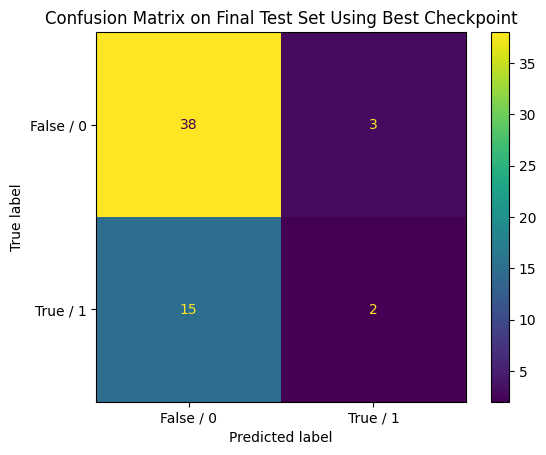

Raw confusion matrix:
[[38  3]
 [15  2]]


In [21]:
cm = confusion_matrix(y_true_test, y_pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["False / 0", "True / 1"]
)

disp.plot()
plt.title("Confusion Matrix on Final Test Set Using Best Checkpoint")
plt.show()

print("Raw confusion matrix:")
print(cm)

## 21. Classification report on the final test set

In [22]:
print(
    classification_report(
        y_true_test,
        y_pred_test,
        target_names=["False / 0", "True / 1"]
    )
)

              precision    recall  f1-score   support

   False / 0       0.72      0.93      0.81        41
    True / 1       0.40      0.12      0.18        17

    accuracy                           0.69        58
   macro avg       0.56      0.52      0.50        58
weighted avg       0.62      0.69      0.62        58



## 22. Optional: inspect predicted probabilities from the best checkpoint

In [23]:
model.eval()

with torch.no_grad():
    logits = model(X_test_tensor.to(device))
    probabilities = torch.sigmoid(logits).detach().cpu().numpy().flatten()

probability_df = pd.DataFrame({
    "true_class": y_true_test,
    "predicted_class": y_pred_test,
    "predicted_probability_class_1": probabilities
})

probability_df.head(20)

,true_class,predicted_class,predicted_probability_class_1
0,0,0,0.131810
1,0,0,0.203076
2,0,0,0.021743
3,0,0,0.052735
4,0,1,0.571455
5,0,0,0.242246
6,1,1,0.892333
7,0,0,0.096616
8,1,0,0.056842
9,0,0,0.191294


## 23. Optional: save the checkpoint history as CSV

In [24]:
# checkpoint_history_df.to_csv("breast_cancer_checkpoint_history.csv", index=False)
# print("Checkpoint history saved to breast_cancer_checkpoint_history.csv")